# Hybrid Strategy — Combining Best Long and Short Models

**Standalone notebook.** Requires only `data_for_experiments.csv`.

Three hybrid strategies tested:

| Strategy | Long leg | Short leg | Hypothesis |
|---|---|---|---|
| H1 — Best legs | Full top-30 XGBoost | Technical-only XGBoost | Use the best model per leg |
| H2 — Regime-gated | Full top-30 XGBoost (skip longs in bear weeks) | Technical-only XGBoost (always) | Avoid long exposure when BTC trend is down |
| H3 — Combined signal | Average signal of both models | Average signal of both models | Ensemble the two models |

All compared against the baseline Full top-30 XGBoost L/S strategy.

In [ ]:
from __future__ import annotations
from pathlib import Path
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd().parent

IN_FILE = BASE_DIR / 'Data/data_for_experiments.csv'
OUT_DIR = BASE_DIR / 'Figures'

TRAIN_CUTOFF = '2024-01'
FORWARD_DAYS = 7
MIN_COINS    = 20
TOP_N        = 30

LABEL_ORDER = ['Strong Avoid', 'Avoid', 'Neutral', 'Buy', 'Strong Buy']
LABEL_MAP   = {'Strong Avoid': 0, 'Avoid': 1, 'Neutral': 2, 'Buy': 3, 'Strong Buy': 4}
BINS        = [0, 0.10, 0.30, 0.70, 0.90, 1.001]
LONG_LABEL  = 'Strong Buy'
SHORT_LABEL = 'Strong Avoid'
BTC_COLOR   = '#F7931A'
ETH_COLOR   = '#627EEA'

LEAKY_COLS = {
    'label', 'forward_return_7d', 'forward_sharpe_7d', 'forward_sharpe_rank',
    'return_1d_rank', 'return_1d_zscore', 'return_7d_rank', 'return_7d_zscore',
    'return_30d_rank', 'return_30d_zscore', 'volatility_30d_rank', 'volatility_30d_zscore',
    'rsi_14_rank', 'rsi_14_zscore', 'macd_hist_rank', 'macd_hist_zscore',
    'bb_pct_rank', 'bb_pct_zscore', 'atr_pct_rank', 'atr_pct_zscore',
    'obv_divergence_rank', 'obv_divergence_zscore', 'stoch_k_rank', 'stoch_k_zscore',
    'adx_rank', 'adx_zscore', 'volume_vs_30d_avg_rank', 'volume_vs_30d_avg_zscore',
    'drawdown_from_90d_peak_rank', 'drawdown_from_90d_peak_zscore',
    'price_vs_ath_rank', 'price_vs_ath_zscore', 'range_position_30d_rank',
    'range_position_30d_zscore', 'consecutive_up_days_rank', 'consecutive_up_days_zscore',
    'consecutive_down_days_rank', 'consecutive_down_days_zscore',
    'coin_age_days_rank', 'coin_age_days_zscore',
    'momentum_score', 'mean_reversion_score', 'trend_score',
    'asset_id', 'year_week', 'date', 'timestamp', 'exchange',
    'pair_symbol', 'source', 'open', 'high', 'low', 'close',
    'granularity', 'is_active',
}

CS_FEATURES = [
    'return_1d', 'return_7d', 'return_30d', 'volatility_30d',
    'rsi_14', 'macd_hist', 'bb_pct', 'atr_pct', 'obv_divergence',
    'stoch_k', 'adx', 'volume_vs_30d_avg', 'drawdown_from_90d_peak',
    'price_vs_ath', 'range_position_30d', 'consecutive_up_days',
    'consecutive_down_days', 'coin_age_days', 'galaxy_score', 'alt_rank',
    'market_cap_usd', 'coin_mcap_share_recalc', 'oi_usd', 'funding_rate',
    'taker_buy_ratio',
]

TECHNICAL_FEATURES = [
    'return_1d', 'return_7d', 'return_30d', 'volatility_30d',
    'rsi_14', 'macd_hist', 'bb_pct', 'bb_width', 'atr_pct', 'atr_14',
    'obv_divergence', 'obv', 'stoch_k', 'stoch_d',
    'adx', 'plus_di', 'minus_di', 'ema_50_vs_200',
    'price_vs_ema50', 'price_vs_ema200',
    'volume_vs_30d_avg', 'volume', 'drawdown_from_90d_peak',
    'price_vs_ath', 'price_vs_atl', 'range_position_30d',
]

XGB_PARAMS = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', verbosity=0,
    random_state=42, n_jobs=-1
)

def prep(d, cols):
    return d[cols].fillna(0).replace([np.inf, -np.inf], 0).clip(-1e9, 1e9)

def cumret(s):
    return (1 + pd.Series(s).fillna(0)).cumprod()

print('Config loaded.')

Config loaded.


## 1. Load data, labels, features, train/test split

In [ ]:
df = pd.read_csv(IN_FILE, low_memory=False)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['asset_id', 'date']).reset_index(drop=True)
df['year_week'] = df['date'].dt.strftime('%G-W%V')
print(f'Loaded: {df.shape[0]:,} rows | {df["asset_id"].nunique()} coins')

def compute_forward_sharpe_7d(group):
    closes, results = group['close'].values, []
    for i in range(len(closes)):
        end = i + FORWARD_DAYS
        if end >= len(closes):
            results.append(np.nan); continue
        window     = closes[i:end]
        daily_rets = np.diff(window) / window[:-1]
        fwd_ret    = (window[-1] - window[0]) / window[0]
        vol        = daily_rets.std() * np.sqrt(365)
        results.append((fwd_ret / vol) if vol > 1e-8 else 0.0)
    return pd.Series(results, index=group.index)

print('Computing forward Sharpe...')
df['forward_sharpe_7d'] = df.groupby('asset_id', group_keys=False).apply(compute_forward_sharpe_7d)
df['forward_return_7d'] = df.groupby('asset_id')['close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1)

weekly = (
    df.dropna(subset=['forward_sharpe_7d'])
    .sort_values('date')
    .groupby(['asset_id', 'year_week']).last().reset_index()
)

def assign_labels(group):
    if len(group) < MIN_COINS:
        return group.assign(label=np.nan, forward_sharpe_rank=np.nan)
    q = group['forward_sharpe_7d'].rank(pct=True)
    group = group.copy()
    group['forward_sharpe_rank'] = q
    group['label'] = pd.cut(q, bins=BINS, labels=LABEL_ORDER, include_lowest=True)
    return group

weekly = (
    weekly.groupby('year_week', group_keys=False).apply(assign_labels)
    .dropna(subset=['label']).reset_index(drop=True)
)
print(f'Weekly snapshots: {len(weekly):,} rows, {weekly["year_week"].nunique()} weeks')

cs_cols = [c for c in CS_FEATURES if c in weekly.columns]
for col in cs_cols:
    weekly[f'{col}_rank']   = weekly.groupby('year_week')[col].transform(lambda x: x.rank(pct=True))
    weekly[f'{col}_zscore'] = weekly.groupby('year_week')[col].transform(
        lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))

cutoff_date = pd.Timestamp(TRAIN_CUTOFF + '-01')
train_df = weekly[pd.to_datetime(weekly['date']) <  cutoff_date].copy()
test_df  = weekly[pd.to_datetime(weekly['date']) >= cutoff_date].copy()
print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

all_features = [
    c for c in weekly.columns
    if c not in LEAKY_COLS
    and weekly[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]
null_rates   = train_df[all_features].isnull().mean()
all_features = [f for f in all_features if null_rates[f] <= 0.30]

y_train = train_df['label'].map(LABEL_MAP)
y_test  = test_df['label'].map(LABEL_MAP)

test_start = pd.Timestamp(TRAIN_CUTOFF + '-01')
btc_w = df[df['asset_id']=='bitcoin'].set_index('date')['close'].resample('W').last().pct_change().loc[test_start:]
eth_w = df[df['asset_id']=='ethereum'].set_index('date')['close'].resample('W').last().pct_change().loc[test_start:]

btc_weekly_ret = (
    df[df['asset_id'] == 'bitcoin'].set_index('date')['close']
    .resample('W').last().pct_change()
)
week_to_btc = {}
for wk in weekly['year_week'].unique():
    last_date = pd.to_datetime(weekly[weekly['year_week'] == wk]['date'].max())
    idx = btc_weekly_ret.index.asof(last_date)
    week_to_btc[wk] = btc_weekly_ret.get(idx, np.nan)

def classify_regime(r):
    if pd.isna(r):  return 'Sideways'
    if r >  0.05:   return 'Bull'
    if r < -0.05:   return 'Bear'
    return 'Sideways'

test_df = test_df.copy()
test_df['regime']    = test_df['year_week'].map(week_to_btc).apply(classify_regime)
test_df['btc_ret_wk'] = test_df['year_week'].map(week_to_btc)
print('\nTest regime distribution (weeks):')
print(test_df.groupby('regime')['year_week'].nunique().rename('weeks'))

Loaded: 211,498 rows | 164 coins
Computing forward Sharpe...
Weekly snapshots: 30,050 rows, 361 weeks
Train: 15,651 | Test: 14,399

Test regime distribution (weeks):
regime
Bear        16
Bull        23
Sideways    73
Name: weeks, dtype: int64


## 2. Feature selection and train both models

In [ ]:
def expand_group(base_names, available):
    expanded = []
    for f in base_names:
        for v in [f, f+'_rank', f+'_zscore']:
            if v in available:
                expanded.append(v)
    return list(dict.fromkeys(expanded))

print('RF pass-1 feature selection...')
rf_sel = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                 max_features='sqrt', class_weight='balanced',
                                 oob_score=True, n_jobs=-1, random_state=42)
rf_sel.fit(prep(train_df, all_features), y_train)
imp = pd.Series(rf_sel.feature_importances_, index=all_features).sort_values(ascending=False)
top30 = imp.head(TOP_N).index.tolist()
print(f'  OOB: {rf_sel.oob_score_*100:.2f}%  |  top-30 selected')

tech_feats = expand_group(TECHNICAL_FEATURES, all_features)
print(f'  Technical features: {len(tech_feats)}')

print('\nTraining Model A: Full top-30 XGBoost (best long)...')
model_A = XGBClassifier(**XGB_PARAMS)
model_A.fit(prep(train_df, top30), y_train)
pred_A = model_A.predict(prep(test_df, top30))
prob_A = model_A.predict_proba(prep(test_df, top30))
acc_A  = accuracy_score(y_test, pred_A)
print(f'  Test accuracy: {acc_A*100:.2f}%')

print('Training Model B: Technical-only XGBoost (best short)...')
model_B = XGBClassifier(**XGB_PARAMS)
model_B.fit(prep(train_df, tech_feats), y_train)
pred_B = model_B.predict(prep(test_df, tech_feats))
prob_B = model_B.predict_proba(prep(test_df, tech_feats))
acc_B  = accuracy_score(y_test, pred_B)
print(f'  Test accuracy: {acc_B*100:.2f}%')

labels_A = pd.Series([LABEL_ORDER[p] for p in pred_A], index=test_df.index)
labels_B = pd.Series([LABEL_ORDER[p] for p in pred_B], index=test_df.index)

print('\nBoth models trained.')

RF pass-1 feature selection...
  OOB: 28.85%  |  top-30 selected
  Technical features: 26

Training Model A: Full top-30 XGBoost (best long)...
  Test accuracy: 38.17%
Training Model B: Technical-only XGBoost (best short)...
  Test accuracy: 38.43%

Both models trained.


## 3. Strategy engine

All strategies go through a single `run_strategy()` function.
For each week it receives which coins to long and which to short,
then computes the P&L.

In [ ]:
def run_strategy(test_df, long_labels_series, short_labels_series, name='Strategy'):
    """
    long_labels_series:  pd.Series indexed like test_df, values from LABEL_ORDER.
                         Coins predicted as LONG_LABEL will be held long.
                         Pass None to skip the long leg entirely that week.
    short_labels_series: same format. Coins predicted as SHORT_LABEL will be shorted.
                         Pass None to skip the short leg.

    Returns a DataFrame with columns: week, long_ret, short_ret, net, long_n, short_n
    """
    rows = []
    for wk in sorted(test_df['year_week'].unique()):
        m = test_df[test_df['year_week'] == wk]

        # Long leg
        if long_labels_series is not None:
            l = long_labels_series[m.index]
            long_coins = m[l == LONG_LABEL]
            long_r     = long_coins['forward_return_7d'].median() if len(long_coins) else np.nan
            long_n     = len(long_coins)
        else:
            long_r, long_n = np.nan, 0

        # Short leg
        if short_labels_series is not None:
            s = short_labels_series[m.index]
            short_coins = m[s == SHORT_LABEL]
            short_r     = short_coins['forward_return_7d'].median() if len(short_coins) else np.nan
            short_n     = len(short_coins)
        else:
            short_r, short_n = np.nan, 0

        
        if pd.notna(long_r) and pd.notna(short_r):
            net = long_r - short_r
        elif pd.notna(long_r):
            net = long_r
        elif pd.notna(short_r):
            net = -short_r
        else:
            net = np.nan

        rows.append({'week': wk, 'long_ret': long_r, 'short_ret': short_r,
                     'net': net, 'long_n': long_n, 'short_n': short_n})

    pnl = pd.DataFrame(rows).set_index('week')
    valid = pnl['net'].dropna()
    print(f'{name}:')
    print(f'  Avg net P&L : {valid.mean()*100:+.2f}%')
    print(f'  Win rate    : {(valid>0).mean()*100:.0f}%')
    print(f'  Ann. spread : {valid.mean()*52*100:+.1f}%')
    print(f'  Cumulative  : {cumret(pnl["net"]).values[-1]:.2f}x')
    return pnl

print('Strategy engine ready.')

Strategy engine ready.


## 4. Run all strategies

In [ ]:
print('=== BASELINE ===')
pnl_base = run_strategy(test_df, labels_A, labels_A,
                         name='Baseline: Model A long + Model A short (Full top-30)')

print('\n=== H1: Best legs ===')
pnl_H1 = run_strategy(test_df, labels_A, labels_B,
                       name='H1: Model A long + Model B short')

print('\n=== H2: Regime-gated ===')
def regime_gate_long(row_week, labels):
    regime = test_df[test_df['year_week'] == row_week]['regime'].iloc[0]
    return None if regime == 'Bear' else labels

rows_H2 = []
for wk in sorted(test_df['year_week'].unique()):
    m      = test_df[test_df['year_week'] == wk]
    regime = m['regime'].iloc[0]
    s = labels_B[m.index]
    short_coins = m[s == SHORT_LABEL]
    short_r     = short_coins['forward_return_7d'].median() if len(short_coins) else np.nan

    if regime == 'Bear':
        long_r, long_n = np.nan, 0
    else:
        l = labels_A[m.index]
        long_coins = m[l == LONG_LABEL]
        long_r     = long_coins['forward_return_7d'].median() if len(long_coins) else np.nan
        long_n     = len(long_coins)

    if pd.notna(long_r) and pd.notna(short_r):
        net = long_r - short_r
    elif pd.notna(short_r):
        net = -short_r
    else:
        net = np.nan

    rows_H2.append({'week': wk, 'long_ret': long_r, 'short_ret': short_r,
                    'net': net, 'long_n': long_n, 'short_n': len(short_coins),
                    'regime': regime})

pnl_H2 = pd.DataFrame(rows_H2).set_index('week')
valid_H2 = pnl_H2['net'].dropna()
print(f'H2: Regime-gated (no longs in Bear weeks):')
print(f'  Avg net P&L : {valid_H2.mean()*100:+.2f}%')
print(f'  Win rate    : {(valid_H2>0).mean()*100:.0f}%')
print(f'  Ann. spread : {valid_H2.mean()*52*100:+.1f}%')
print(f'  Cumulative  : {cumret(pnl_H2["net"]).values[-1]:.2f}x')
print(f'  Bear weeks (long skipped): {(pnl_H2["regime"]=="Bear").sum()}')

print('\n=== H3: Ensemble (combined signal) ===')
prob_SB_A = prob_A[:, 4]  # Strong Buy prob from Model A
prob_SA_A = prob_A[:, 0]  # Strong Avoid prob from Model A
prob_SB_B = prob_B[:, 4]  # Strong Buy prob from Model B
prob_SA_B = prob_B[:, 0]  # Strong Avoid prob from Model B

test_df = test_df.copy()
test_df['ensemble_long_score']  = (pd.Series(prob_SB_A, index=test_df.index) +
                                    pd.Series(prob_SB_B, index=test_df.index)) / 2
test_df['ensemble_short_score'] = (pd.Series(prob_SA_A, index=test_df.index) +
                                    pd.Series(prob_SA_B, index=test_df.index)) / 2

def assign_ensemble_labels(group):
    g = group.copy()
    long_thresh  = g['ensemble_long_score'].quantile(0.90)
    short_thresh = g['ensemble_short_score'].quantile(0.90)
    g['ensemble_label'] = 'Neutral'
    g.loc[g['ensemble_long_score']  >= long_thresh,  'ensemble_label'] = 'Strong Buy'
    g.loc[g['ensemble_short_score'] >= short_thresh, 'ensemble_label'] = 'Strong Avoid'
    return g

test_df = test_df.groupby('year_week', group_keys=False).apply(assign_ensemble_labels)
labels_ens = test_df['ensemble_label']

pnl_H3 = run_strategy(test_df, labels_ens, labels_ens,
                       name='H3: Ensemble (avg Model A + Model B probabilities)')

=== BASELINE ===
Baseline: Model A long + Model A short (Full top-30):
  Avg net P&L : +6.16%
  Win rate    : 71%
  Ann. spread : +320.1%
  Cumulative  : 243.75x

=== H1: Best legs ===
H1: Model A long + Model B short:
  Avg net P&L : +6.61%
  Win rate    : 70%
  Ann. spread : +344.0%
  Cumulative  : 427.28x

=== H2: Regime-gated ===
H2: Regime-gated (no longs in Bear weeks):
  Avg net P&L : +4.97%
  Win rate    : 69%
  Ann. spread : +258.6%
  Cumulative  : 103.27x
  Bear weeks (long skipped): 16

=== H3: Ensemble (combined signal) ===
H3: Ensemble (avg Model A + Model B probabilities):
  Avg net P&L : +1.41%
  Win rate    : 61%
  Ann. spread : +73.1%
  Cumulative  : 3.89x


## 5. Per-week breakdown and regime analysis

In [ ]:
regime_map = test_df.groupby('year_week')['regime'].first()
for pnl in [pnl_base, pnl_H1, pnl_H3]:
    pnl['regime'] = pnl.index.map(regime_map)

strategies = {
    'Baseline (A/A)':  pnl_base,
    'H1 (A long / B short)': pnl_H1,
    'H2 (regime-gated)': pnl_H2,
    'H3 (ensemble)':   pnl_H3,
}

print(f'{"Strategy":<25}  {"Bull":>8}  {"Bear":>8}  {"Sideways":>10}  {"Overall":>9}')
print('-' * 68)
for name, pnl in strategies.items():
    overall = pnl['net'].dropna().mean() * 100
    results = []
    for regime in ['Bull', 'Bear', 'Sideways']:
        sub = pnl[pnl['regime'] == regime]['net'].dropna()
        results.append(f'{sub.mean()*100:+.2f}%' if len(sub) else '  N/A')
    print(f'{name:<25}  {results[0]:>8}  {results[1]:>8}  {results[2]:>10}  {overall:>+8.2f}%')

Strategy                       Bull      Bear    Sideways    Overall
--------------------------------------------------------------------
Baseline (A/A)               +4.96%   +14.50%      +4.68%     +6.16%
H1 (A long / B short)        +4.34%   +15.42%      +5.39%     +6.61%
H2 (regime-gated)            +4.34%    +3.64%      +5.46%     +4.97%
H3 (ensemble)                -0.06%    +0.17%      +2.14%     +1.41%


## 6. Figure 1 — Cumulative return: all strategies vs BTC/ETH

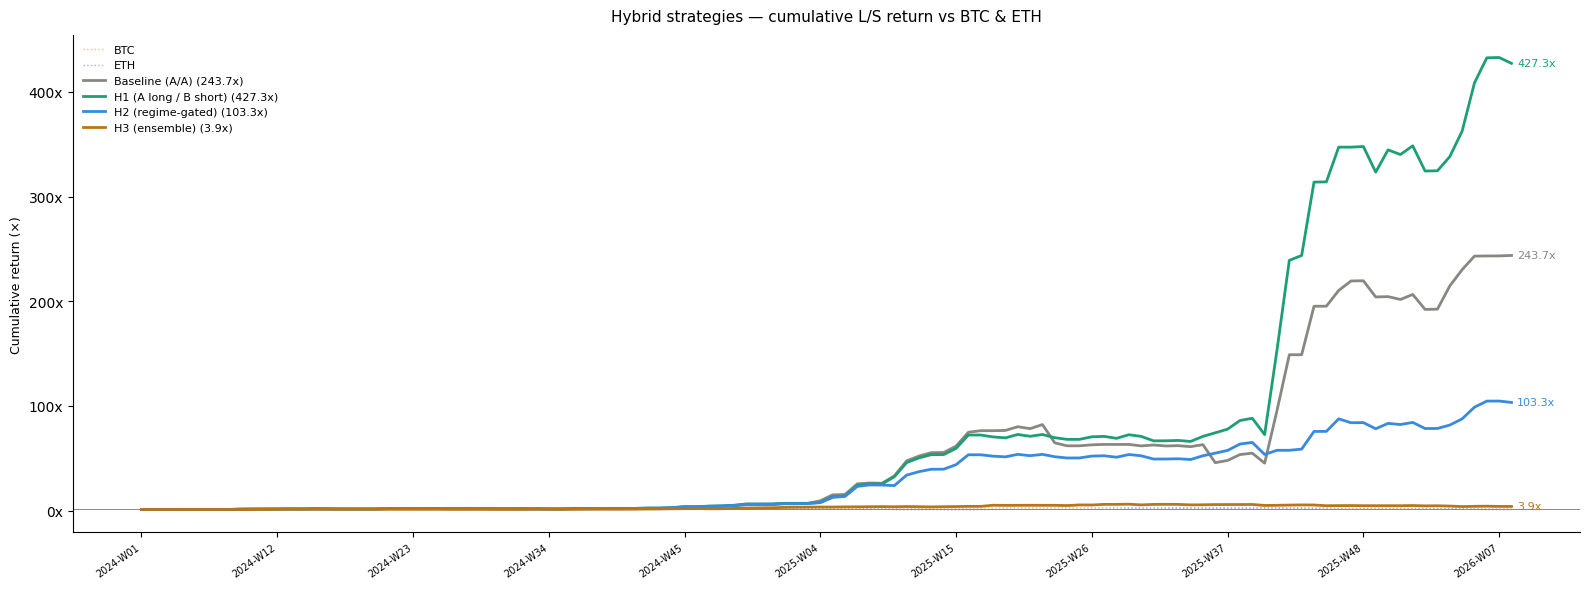

Saved -> hybrid_cumulative_all.png


In [7]:
wk_labels = sorted(test_df['year_week'].unique())
step      = max(1, len(wk_labels) // 10)
n_weeks   = len(wk_labels)

btc_cum = cumret(btc_w.reset_index(drop=True).iloc[:n_weeks])
eth_cum = cumret(eth_w.reset_index(drop=True).iloc[:n_weeks])

STRAT_COLORS = {
    'Baseline (A/A)':       '#888780',
    'H1 (A long / B short)':'#1D9E75',
    'H2 (regime-gated)':    '#378ADD',
    'H3 (ensemble)':        '#BA7517',
}

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')

ax.plot(range(n_weeks), btc_cum.values, color=BTC_COLOR, lw=1.0, ls=':', alpha=0.6, label='BTC')
ax.plot(range(n_weeks), eth_cum.values, color=ETH_COLOR, lw=1.0, ls=':', alpha=0.6, label='ETH')
ax.axhline(1.0, color='#888780', lw=0.7)

for name, pnl in strategies.items():
    cum = cumret(pnl['net'])
    final = cum.values[-1]
    ax.plot(range(len(cum)), cum.values, color=STRAT_COLORS[name], lw=2.0,
            label=f'{name} ({final:.1f}x)')
    ax.annotate(f'{final:.1f}x', xy=(len(cum)-1, final),
                xytext=(4, 0), textcoords='offset points',
                va='center', fontsize=8, color=STRAT_COLORS[name], fontweight='500')

ax.set_xticks(range(0, n_weeks, step))
ax.set_xticklabels(wk_labels[::step], rotation=35, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.0f}x'))
ax.set_ylabel('Cumulative return (×)', fontsize=9)
ax.set_title('Hybrid strategies — cumulative L/S return vs BTC & ETH', fontsize=11, fontweight='500', pad=10)
ax.legend(fontsize=8, framealpha=0, loc='upper left')
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')

plt.tight_layout()
p = OUT_DIR / 'hybrid_cumulative_all.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

## 7. Figure 2 — Long / Short / Net legs side by side for H1

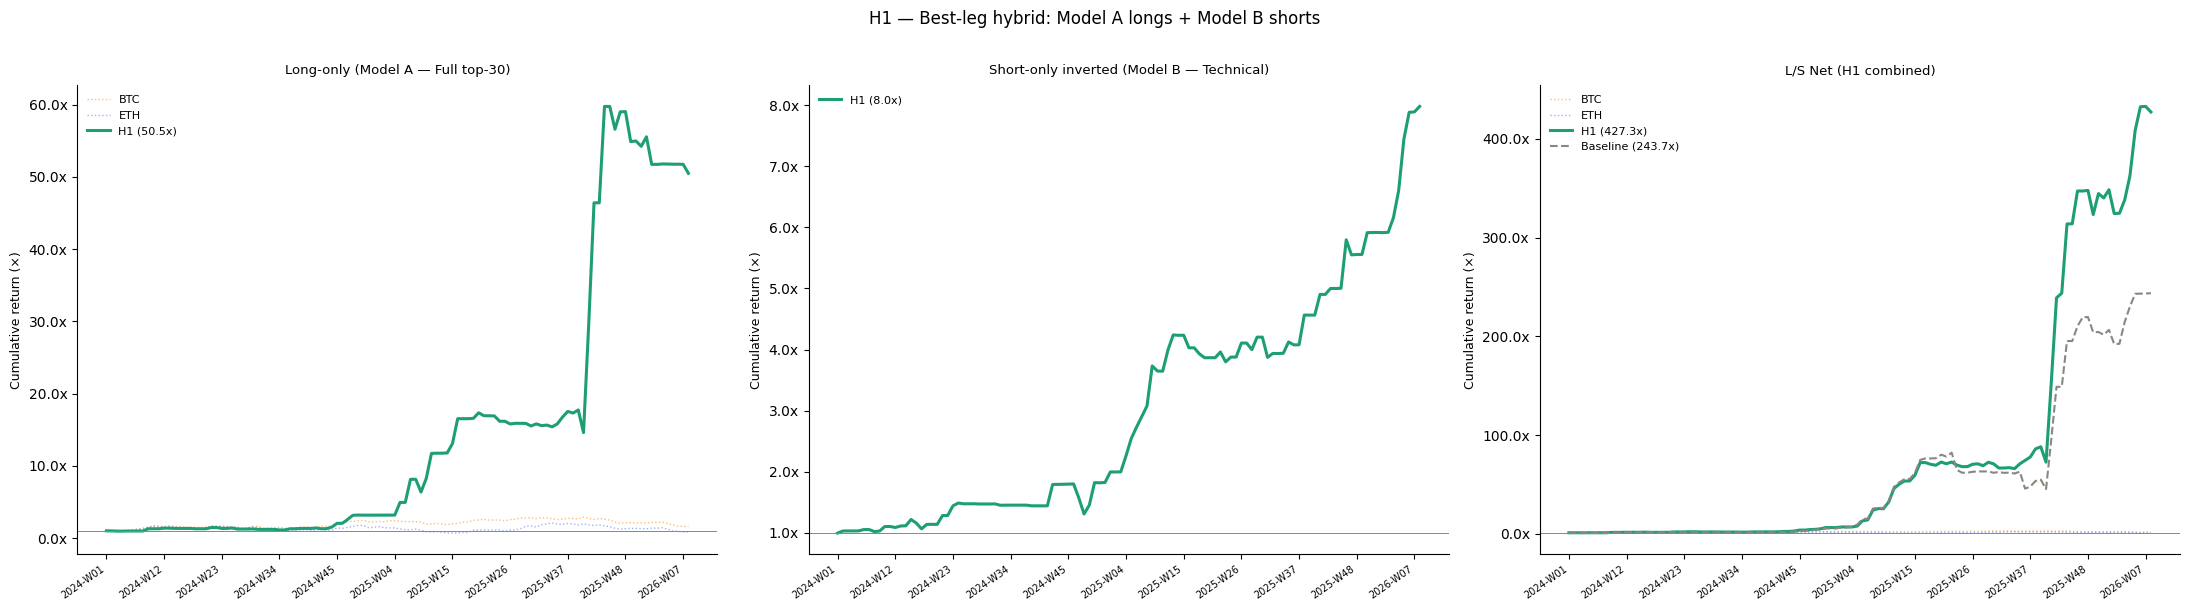

Saved -> hybrid_H1_legs.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor('white')

for ax, (leg, title, show_bench) in zip(axes, [
    ('long_ret',  'Long-only (Model A — Full top-30)',           True),
    ('short_ret', 'Short-only inverted (Model B — Technical)',   False),
    ('net',       'L/S Net (H1 combined)',                       True),
]):
    if show_bench:
        ax.plot(range(n_weeks), btc_cum.values, color=BTC_COLOR, lw=1.0, ls=':', alpha=0.6, label='BTC')
        ax.plot(range(n_weeks), eth_cum.values, color=ETH_COLOR, lw=1.0, ls=':', alpha=0.6, label='ETH')

    series = pnl_H1[leg] if leg != 'short_ret' else -pnl_H1[leg]
    cum    = cumret(series)
    ax.plot(range(len(cum)), cum.values, color='#1D9E75', lw=2.2,
            label=f'H1 ({cum.values[-1]:.1f}x)')

    # Also show baseline for comparison on net panel
    if leg == 'net':
        cum_base = cumret(pnl_base['net'])
        ax.plot(range(len(cum_base)), cum_base.values, color='#888780', lw=1.5, ls='--',
                label=f'Baseline ({cum_base.values[-1]:.1f}x)')

    ax.axhline(1.0, color='#888780', lw=0.7)
    ax.set_xticks(range(0, n_weeks, step))
    ax.set_xticklabels(wk_labels[::step], rotation=35, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.1f}x'))
    ax.set_ylabel('Cumulative return (×)', fontsize=9)
    ax.set_title(title, fontsize=9.5, fontweight='500', pad=8)
    ax.legend(fontsize=8, framealpha=0, loc='upper left')
    ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')

plt.suptitle('H1 — Best-leg hybrid: Model A longs + Model B shorts',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'hybrid_H1_legs.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

## 8. Figure 3 — Regime breakdown: weekly net P&L by regime per strategy

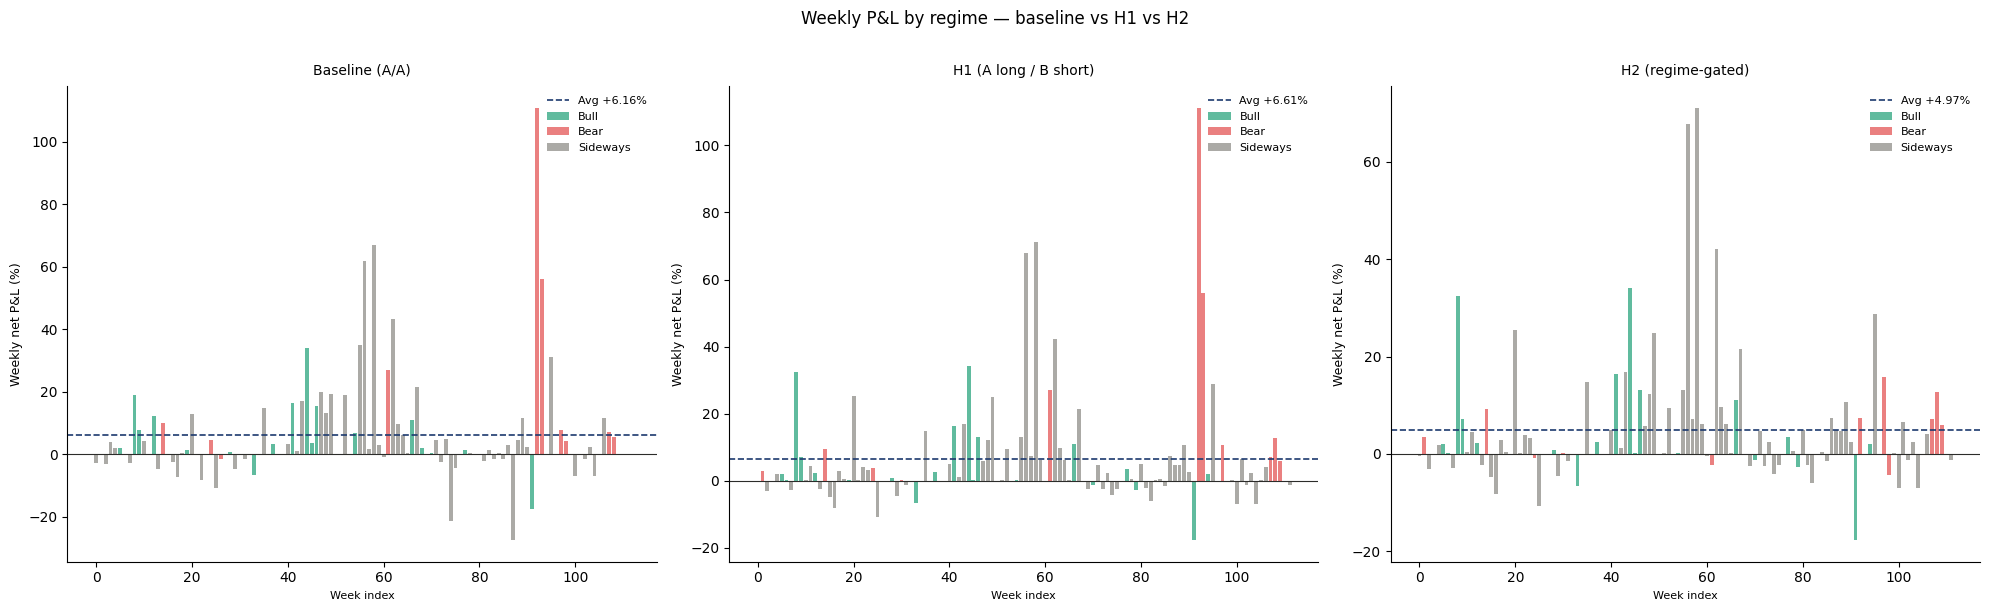

Saved -> hybrid_regime_pnl.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('white')
regime_colors = {'Bull': '#1D9E75', 'Bear': '#E24B4A', 'Sideways': '#888780'}

for ax, (name, pnl) in zip(axes, [
    ('Baseline (A/A)',        pnl_base),
    ('H1 (A long / B short)', pnl_H1),
    ('H2 (regime-gated)',     pnl_H2),
]):
    regime_col = pnl['regime'] if 'regime' in pnl.columns else pnl.index.map(regime_map)
    for regime in ['Bull', 'Bear', 'Sideways']:
        sub = pnl[regime_col == regime]['net'].dropna()
        if len(sub) == 0: continue
        weeks_idx = [list(pnl.index).index(w) for w in sub.index if w in pnl.index]
        ax.bar(weeks_idx, sub.values * 100,
               color=regime_colors[regime], alpha=0.7, label=regime, width=0.8)

    ax.axhline(0, color='#2C2C2A', lw=0.8)
    avg = pnl['net'].dropna().mean() * 100
    ax.axhline(avg, color='#1D3A6E', lw=1.2, ls='--', label=f'Avg {avg:+.2f}%')
    ax.set_title(name, fontsize=10, fontweight='500', pad=8)
    ax.set_ylabel('Weekly net P&L (%)', fontsize=9)
    ax.set_xlabel('Week index', fontsize=8)
    # Show legend only once, deduplicated
    handles, labels_list = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_list, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, framealpha=0)
    ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')

plt.suptitle('Weekly P&L by regime — baseline vs H1 vs H2',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'hybrid_regime_pnl.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

## 9. Final summary table

In [10]:
print('='*80)
print('HYBRID STRATEGY SUMMARY')
print('='*80)
print(f'{"Strategy":<28} {"Cum return":>11} {"Avg P&L":>9} {"Win rate":>9} {"Ann. spread":>12}')
print('-'*72)

summary_rows = []
for name, pnl in strategies.items():
    s = pnl['net'].dropna()
    cum   = cumret(pnl['net']).values[-1]
    avg   = s.mean() * 100
    wr    = (s > 0).mean() * 100
    ann   = avg * 52
    print(f'{name:<28} {cum:>9.1f}x  {avg:>+7.2f}%  {wr:>7.0f}%  {ann:>+10.1f}%')
    summary_rows.append({'Strategy': name, 'Cum return (x)': round(cum,1),
                         'Avg weekly P&L (%)': round(avg,2),
                         'Win rate (%)': round(wr,1), 'Ann. (%)': round(ann,1)})

pd.DataFrame(summary_rows).to_csv(DYPLOM / 'hybrid_summary.csv', index=False)

print('\n=== Per-regime breakdown (avg weekly net P&L) ===')
print(f'{"Strategy":<28} {"Bull":>9} {"Bear":>9} {"Sideways":>10}')
print('-'*60)
for name, pnl in strategies.items():
    rc = pnl['regime'] if 'regime' in pnl.columns else pnl.index.map(regime_map)
    vals = []
    for r in ['Bull','Bear','Sideways']:
        sub = pnl[rc == r]['net'].dropna()
        vals.append(f'{sub.mean()*100:+.2f}%' if len(sub) else '  N/A')
    print(f'{name:<28} {vals[0]:>9} {vals[1]:>9} {vals[2]:>10}')

print('\nSaved -> hybrid_summary.csv')
print('\nFigures:')
for f in sorted(OUT_DIR.iterdir()):
    if 'hybrid' in f.name:
        print(f'  {f.name}')

HYBRID STRATEGY SUMMARY
Strategy                      Cum return   Avg P&L  Win rate  Ann. spread
------------------------------------------------------------------------
Baseline (A/A)                   243.7x    +6.16%       71%      +320.1%
H1 (A long / B short)            427.3x    +6.61%       70%      +344.0%
H2 (regime-gated)                103.3x    +4.97%       69%      +258.6%
H3 (ensemble)                      3.9x    +1.41%       61%       +73.1%

=== Per-regime breakdown (avg weekly net P&L) ===
Strategy                          Bull      Bear   Sideways
------------------------------------------------------------
Baseline (A/A)                  +4.96%   +14.50%     +4.68%
H1 (A long / B short)           +4.34%   +15.42%     +5.39%
H2 (regime-gated)               +4.34%    +3.64%     +5.46%
H3 (ensemble)                   -0.06%    +0.17%     +2.14%

Saved -> hybrid_summary.csv

Figures:
  hybrid_H1_legs.png
  hybrid_cumulative_all.png
  hybrid_regime_pnl.png
